In [ ]:
#input files. Do not touch.
import pandas as pd
import glob
import re

# Load training.csv
training = pd.read_csv("training.csv")

# Load all evalN.csv files into separate dataframes named evaluationN
eval_files = glob.glob("eval*.csv")
for f in eval_files:
    match = re.search(r'eval(\d+)\.csv', f)
    if match:
        n = match.group(1)
        df_name = f"evaluation{n}"
        globals()[df_name] = pd.read_csv(f)

In [ ]:

import random

def ids(eval_df):
    # result_df needs to be the same as eval_df, with the predicted_attack column
    result_df = eval_df.copy()
    ## TODO
    result_df["predicted_attack"] = 0  # all packets are initialized as non-attack-packets (this can be changed at will)
    return result_df


running evaluation1
running evaluation2
running evaluation3
running evaluation4
running evaluation5
running evaluation6

evaluation1 Evaluation Metrics:
  Accuracy: 0.5051
  Precision: 0.4018
  Recall: 0.5083
  F1_score: 0.4488

evaluation2 Evaluation Metrics:
  Accuracy: 0.5087
  Precision: 0.1395
  Recall: 0.5096
  F1_score: 0.2190

evaluation3 Evaluation Metrics:
  Accuracy: 0.4941
  Precision: 0.0210
  Recall: 0.4667
  F1_score: 0.0401

evaluation4 Evaluation Metrics:
  Accuracy: 0.5042
  Precision: 0.3041
  Recall: 0.5055
  F1_score: 0.3798

evaluation5 Evaluation Metrics:
  Accuracy: 0.4991
  Precision: 0.0224
  Recall: 0.4929
  F1_score: 0.0428

evaluation6 Evaluation Metrics:
  Accuracy: 0.5060
  Precision: 0.0268
  Recall: 0.5051
  F1_score: 0.0508

Average Evaluation Metrics:
  Accuracy: 0.5029
  Precision: 0.1526
  Recall: 0.4980
  F1_score: 0.1969


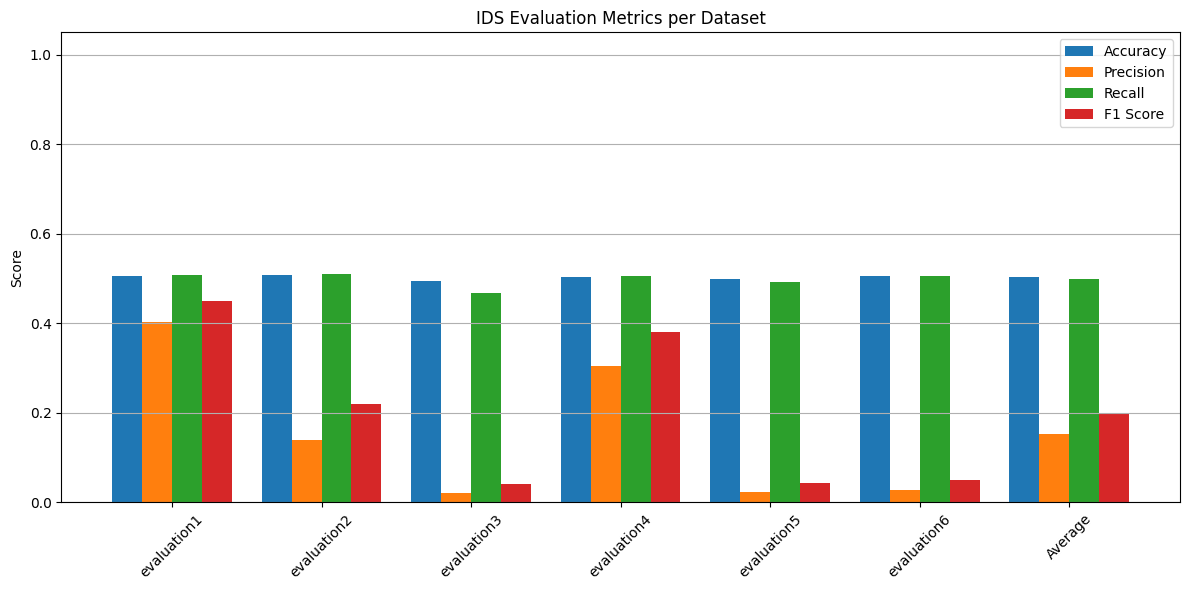


Total Elapsed Time: 1.73 seconds


In [ ]:
#evaluation sequence. Do not touch.
import time  # Add this
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

start_time = time.time()  # Start timing

evaluation_metrics = {}
all_globals = list(globals().items())

# Loop through evaluation dataframes
for name, df in all_globals:
    if name.startswith("evaluation") and isinstance(df, pd.DataFrame):
        # Run IDS
        #print("running " + name)
        detected_df = ids(df)
        
        # Compare predictions to ground truth
        y_true = detected_df['attack']
        y_pred = detected_df['predicted_attack']
        
        # Compute metrics
        metrics = {
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1_score': f1_score(y_true, y_pred, zero_division=0),
        }
        
        evaluation_metrics[name] = metrics

# Compute average metrics
avg_metrics = {
    metric: np.mean([metrics[metric] for metrics in evaluation_metrics.values()])
    for metric in ['accuracy', 'precision', 'recall', 'f1_score']
}
evaluation_metrics['Average'] = avg_metrics

# Display metrics
for name, metrics in evaluation_metrics.items():
    print(f"\n{name} Evaluation Metrics:")
    for metric, value in metrics.items():
        print(f"  {metric.capitalize()}: {value:.4f}")

# Plotting
labels = list(evaluation_metrics.keys())
x = np.arange(len(labels))
width = 0.2

# Prepare metric lists
accuracy = [evaluation_metrics[label]['accuracy'] for label in labels]
precision = [evaluation_metrics[label]['precision'] for label in labels]
recall = [evaluation_metrics[label]['recall'] for label in labels]
f1 = [evaluation_metrics[label]['f1_score'] for label in labels]

# Create the bar chart
plt.figure(figsize=(12, 6))
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, precision, width, label='Precision')
plt.bar(x + 0.5*width, recall, width, label='Recall')
plt.bar(x + 1.5*width, f1, width, label='F1 Score')

plt.xticks(x, labels, rotation=45)
plt.ylabel('Score')
plt.title('IDS Evaluation Metrics per Dataset')
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.grid(axis='y')
plt.show()

# End timing
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTotal Elapsed Time: {elapsed_time:.2f} seconds")
